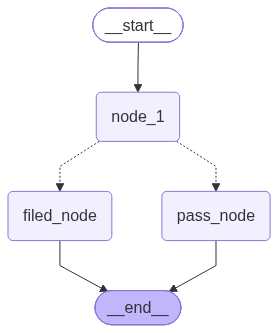

你的成绩合格
{'score': 80, 'result': '考试合格'}


In [4]:
from typing import TypedDict, Annotated

from IPython.core.display import display_png, Image
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from typing_extensions import Literal


# =================1. 定义State数据结构，默认Reducer=================
class CustomReducerState(TypedDict):
    # 每一个字段都可以定义处理函数,是覆盖还是还是追加取决于函数决定
    score: int
    result: str

# 开始节点
def node_1(state: CustomReducerState):
    # 请输入考试成绩
    user_input = int(input('请输入考试成绩'))
    # 设置count字段的值,nodes字段的值则是累加
    return {"score": user_input}

# 合格节点
def pass_node(state: CustomReducerState):
     print('你的成绩合格')
     return {
         "result":"考试合格"
     }

# 不合格节点
def filed_node(state: CustomReducerState):
     print(f"node_2收到的count是: count={state['score']}")
    # 设置count字段的值,nodes字段的值则是累加
     return {
         "result":"考试失败"
     }

# 路由节点
def score_router(state: CustomReducerState) -> Literal['pass_node','filed_node']:
    if state['score'] >= 60:
        return 'pass_node'
    else:
        return 'filed_node'




# 创建图表构建器
graph_builder = StateGraph(CustomReducerState)

# 注册两个节点
graph_builder.add_node("node_1", node_1)
graph_builder.add_node("pass_node", pass_node)
graph_builder.add_node("filed_node", filed_node)


# 定义线的连接
graph_builder.add_edge(START, "node_1")
# node_1连接到路由节点
graph_builder.add_conditional_edges("node_1",score_router)

# 直接定义分支后的节点到新节点
graph_builder.add_edge("pass_node", END)
graph_builder.add_edge("filed_node", END)


# 创建完整的图表
graph = graph_builder.compile()

# 画出工作流
display_png(Image(graph.get_graph().draw_mermaid_png()))

# =================4.调用Graph，传入默认State值=================
result = graph.invoke({"score": 0, "result": ""})
print(result)